В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import drive

# дані вже завантажила з каггл тому через маунт драйв роблю тут

drive.mount('/content/drive')

data_dir = '/content/drive/MyDrive/ML1/data/kaggle_data'
raw_df = pd.read_csv(f'{data_dir}/train.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# stratify
train_df, val_df = train_test_split(raw_df, test_size=0.2,
                                    stratify=raw_df['Exited'], random_state=42)

print('train:', train_df.shape, ' val:', val_df.shape)
print('Частка класу 1 в train:', round(train_df['Exited'].mean(), 4))
print('Частка класу 1 в val:  ', round(val_df['Exited'].mean(), 4))

train: (12000, 14)  val: (3000, 14)
Частка класу 1 в train: 0.2035
Частка класу 1 в val:   0.2033


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [25]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 7180 to 9360
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               12000 non-null  int64  
 1   CustomerId       12000 non-null  float64
 2   Surname          12000 non-null  object 
 3   CreditScore      12000 non-null  float64
 4   Geography        12000 non-null  object 
 5   Gender           12000 non-null  object 
 6   Age              12000 non-null  float64
 7   Tenure           12000 non-null  float64
 8   Balance          12000 non-null  float64
 9   NumOfProducts    12000 non-null  float64
 10  HasCrCard        12000 non-null  float64
 11  IsActiveMember   12000 non-null  float64
 12  EstimatedSalary  12000 non-null  float64
 13  Exited           12000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.4+ MB


In [26]:
train_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7180,7180,15652218.0,Mays,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24,0.0
10393,10393,15592937.0,Ch'eng,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31,0.0
80,80,15774586.0,Ch'in,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01,0.0
3365,3365,15780572.0,K?,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98,0.0
12236,12236,15642099.0,Trevisani,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76,0.0


In [27]:
# id - технічний, CustomerId - дублікати, Surname не має сенсу тримати коли є айді колонка (інт) з якою швидше працювати
input_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
              'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
              'EstimatedSalary']
target_col = 'Exited'

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [28]:
numeric_cols = train_inputs.select_dtypes(include='number').columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()

print('Числові:       ', numeric_cols)
print('Категоріальні: ', categorical_cols)

Числові:        ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Категоріальні:  ['Geography', 'Gender']


4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [29]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 4/1 Пропуски: перевіряємо якщо їх немає, імпутація не потрібна
print('Пропусків: в трейн -', train_inputs.isna().sum().sum(), ', в валідації - ', val_inputs.isna().sum().sum())

Пропусків: в трейн - 0 , в валідації -  0


In [30]:
# 4/2 Масштабування: логістична регресія чутлива до масштабу
#    (Age ~18-92 vs Salary ~0-200000). fit ТІЛЬКИ на train!

scaler = StandardScaler().fit(train_inputs[numeric_cols])
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

In [31]:
# 4/3 Кодування: модель приймає лише числа, Geography/Gender то бінарні колонки
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

display(train_inputs.head(5))
display(val_inputs.head(5))

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
7180,0.320187,France,Male,-0.944682,-1.447264,1.475464,-1.108193,0.515062,1.016977,0.569450,1.0,0.0,0.0,0.0,1.0
10393,0.347838,France,Female,0.161227,-1.087792,2.254434,-1.108193,0.515062,-0.983306,0.603803,1.0,0.0,0.0,1.0,0.0
80,0.638166,Germany,Male,-0.330288,0.350096,1.223831,0.769304,0.515062,-0.983306,1.238026,0.0,1.0,0.0,0.0,1.0
3365,0.140460,Spain,Male,2.495924,-1.806736,-0.717950,0.769304,-1.941514,1.016977,-1.457116,0.0,0.0,1.0,0.0,1.0
12236,0.665816,France,Male,-2.050591,-0.728320,-0.717950,0.769304,0.515062,1.016977,0.670629,1.0,0.0,0.0,0.0,1.0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
6490,0.762592,Germany,Male,1.021379,-1.447264,1.214543,4.524299,0.515062,1.016977,-0.988144,0.0,1.0,0.0,0.0,1.0
3646,-0.910252,France,Male,0.406985,-0.009376,-0.717950,0.769304,0.515062,1.016977,-1.750392,1.0,0.0,0.0,0.0,1.0
5306,0.997620,France,Female,0.038348,-1.087792,-0.717950,0.769304,-1.941514,1.016977,-0.022404,1.0,0.0,0.0,1.0,0.0
652,0.195761,France,Female,0.652742,-0.368848,1.881867,-1.108193,-1.941514,1.016977,-0.139723,1.0,0.0,0.0,1.0,0.0
2627,0.264887,Spain,Female,-0.944682,-0.368848,-0.717950,0.769304,0.515062,-0.983306,0.563519,0.0,0.0,1.0,1.0,0.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [32]:
import os

processed_dir = f'{data_dir}/processed'
os.makedirs(processed_dir, exist_ok=True)

train_inputs.to_parquet(f'{processed_dir}/train_inputs.parquet')
val_inputs.to_parquet(f'{processed_dir}/val_inputs.parquet')
train_targets.to_frame().to_parquet(f'{processed_dir}/train_targets.parquet')
val_targets.to_frame().to_parquet(f'{processed_dir}/val_targets.parquet')

os.listdir(processed_dir)

['train_inputs.parquet',
 'val_inputs.parquet',
 'train_targets.parquet',
 'val_targets.parquet']

6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [33]:
from sklearn.linear_model import LogisticRegression

X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]

model = LogisticRegression(solver='liblinear')
model.fit(X_train, train_targets)

LogisticRegression(solver='liblinear')

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

=== Train ===
AUROC:    0.8825
F1 Score: 0.6402


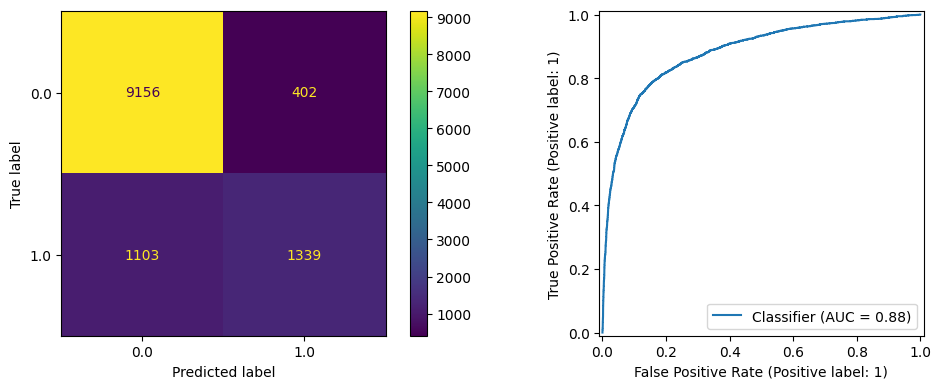

=== Validation ===
AUROC:    0.8797
F1 Score: 0.639


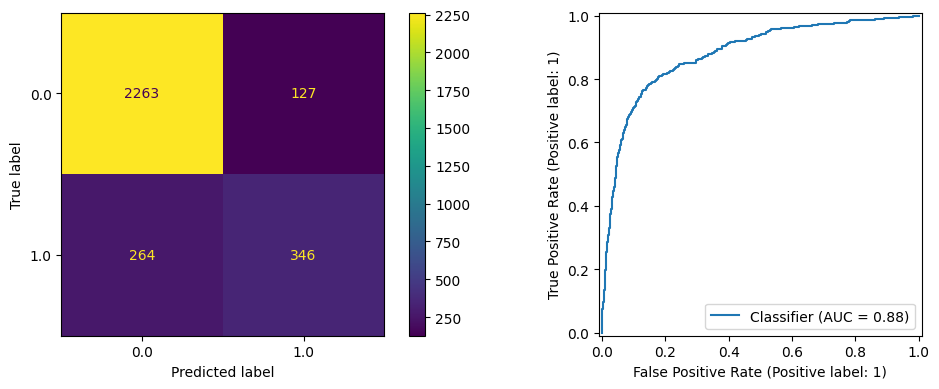

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay,
                             roc_auc_score, f1_score)

def evaluate(name, X, y):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= 0.5).astype(int)
    print(f'=== {name} ===')
    print('AUROC:   ', round(roc_auc_score(y, probs), 4))
    print('F1 Score:', round(f1_score(y, preds), 4))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    ConfusionMatrixDisplay.from_predictions(y, preds, ax=axes[0])
    RocCurveDisplay.from_predictions(y, probs, ax=axes[1])
    plt.tight_layout(); plt.show()

evaluate('Train', X_train, train_targets)
evaluate('Validation', X_val, val_targets)

Тренувальна та валідаційна мнетрики дуже схожі, нема оверфітингу.
AUROC:    0.8825 - частка успіхів у передбаченні тих хто пішов, тобто прості лінійні зв язки за віком, активністю тощо вже дають непоганий результат.
На валідаційних даних модель прогавила 264 на фальснегативах.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [35]:
import numpy as np
from sklearn.metrics import accuracy_score

majority_class = train_targets.mode()[0]   # клас 0

baseline_train = np.full(len(train_targets), majority_class)
baseline_val = np.full(len(val_targets), majority_class)

print('Baseline accuracy: train',
      round(accuracy_score(train_targets, baseline_train), 4),
      '/ val', round(accuracy_score(val_targets, baseline_val), 4))
print('Model accuracy:    train',
      round(accuracy_score(train_targets, model.predict(X_train)), 4),
      '/ val', round(accuracy_score(val_targets, model.predict(X_val)), 4))

Baseline accuracy: train 0.7965 / val 0.7967
Model accuracy:    train 0.8746 / val 0.8697


Baseline accuracy: біля 79 відсотків, без навчання показує що багато клієнтів справді залишаються. Сама модель дає точність приблизно 87 це на 8 відсотків краще за бейслайн. Якість моделі задовільна.


9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [36]:
import joblib

# зберігаємо модель РАЗОМ зі scaler/encoder - без них нові дані не підготувати
joblib.dump({'model': model, 'scaler': scaler, 'encoder': encoder,
             'numeric_cols': numeric_cols, 'categorical_cols': categorical_cols,
             'encoded_cols': encoded_cols}, 'log_reg.joblib')

model_2 = joblib.load('log_reg.joblib')['model']
model_2

LogisticRegression(solver='liblinear')

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [37]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    input_df = input_df.copy()   # додано: не псуємо оригінальний датафрейм
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]
    return prob

In [38]:
predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, raw_df[:5])

array([0.00563657, 0.03331576, 0.3809349 , 0.38052591, 0.97925368])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [39]:
test_raw_df = pd.read_csv(f'{data_dir}/test.csv')
test_raw_df['Exited'] = predict_raw_df(scaler, encoder, numeric_cols,
                                       categorical_cols, test_raw_df)
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.069393
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.033314
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.153586
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.199192
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.054281


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [40]:
submission = pd.read_csv(f'{data_dir}/sample_submission.csv')

# зіставляємо за id, а не за порядком рядків
submission['Exited'] = submission['id'].map(test_raw_df.set_index('id')['Exited'])

display(submission.head())
submission.to_csv('submission_log_reg.csv', index=False)   # index=False - обов'язково

,id,Exited
0,15000,0.069393
1,15001,0.033314
2,15002,0.153586
3,15003,0.199192
4,15004,0.054281
